<a href="https://colab.research.google.com/github/Rima6699/Amir-datmin/blob/main/2304020182_UTS_DATAMINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**KLASIFIKASI KUALITAS ANGGUR — WINE QUALITY**

1. IMPORT LIBRARY

In [22]:
import pandas as pd                                   # Manipulasi data tabular
import numpy as np                                    # Komputasi numerik
import matplotlib.pyplot as plt                       # Plotting
import seaborn as sns                                 # Visualisasi statistik

from sklearn.model_selection import train_test_split  # Split data train/val
from sklearn.preprocessing import StandardScaler      # Normalisasi fitur
from sklearn.ensemble import RandomForestClassifier   # Model utama
from sklearn.metrics import (
    accuracy_score,           # Akurasi keseluruhan
    classification_report,    # Precision, Recall, F1 per kelas
    confusion_matrix,         # Matriks konfusi
    ConfusionMatrixDisplay     # Visualisasi confusion matrix
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white',
                     'axes.titleweight': 'bold'})

def section(title, icon=''):
    bar = '═' * 62
    print(f'\n╔{bar}╗')
    print(f'║  {icon}  {title:<59}║')
    print(f'╚{bar}╝')

2. LOAD DATASET

In [23]:
section('LOAD DATASET', '📂')

from google.colab import files

print('\n  📎  Upload file: data_training.csv')
up_train = files.upload()
print('\n  📎  Upload file: data_testing.csv')
up_test  = files.upload()

train = pd.read_csv(list(up_train.keys())[0])
test  = pd.read_csv(list(up_test.keys())[0])

print(f'\n  ✅  Training set : {train.shape[0]:,} baris × {train.shape[1]} kolom')
print(f'  ✅  Testing set  : {test.shape[0]:,} baris × {test.shape[1]} kolom')

print('\n  ── 5 Data Teratas — Training ──────────────────────────────')
display(train.head())

print('\n  ── 5 Data Teratas — Testing ───────────────────────────────')
display(test.head())

# Info distribusi target
print('\n  ── Distribusi Kelas Target (quality) ──────────────────────')
dist = train['quality'].value_counts().sort_index()
print(dist.to_frame().T)


╔══════════════════════════════════════════════════════════════╗
║  📂  LOAD DATASET                                               ║
╚══════════════════════════════════════════════════════════════╝

  📎  Upload file: data_training.csv


Saving data_training.csv to data_training (2).csv

  📎  Upload file: data_testing.csv


Saving data_testing.csv to data_testing (2).csv

  ✅  Training set : 857 baris × 13 kolom
  ✅  Testing set  : 286 baris × 12 kolom

  ── 5 Data Teratas — Training ──────────────────────────────


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3000,0.7400,0.0800,1.7000,0.0940,10.0000,45.0000,0.9958,3.2400,0.5000,9.8000,5,1366
1,8.1000,0.5750,0.2200,2.1000,0.0770,12.0000,65.0000,0.9967,3.2900,0.5100,9.2000,5,103
2,10.1000,0.4300,0.4000,2.6000,0.0920,13.0000,52.0000,0.9983,3.2200,0.6400,10.0000,7,942
3,12.9000,0.5000,0.5500,2.8000,0.0720,7.0000,24.0000,1.0001,3.0900,0.6800,10.9000,6,811
4,8.4000,0.3600,0.3200,2.2000,0.0810,32.0000,79.0000,0.9964,3.3000,0.7200,11.0000,6,918



  ── 5 Data Teratas — Testing ───────────────────────────────


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8000,0.6100,0.0400,1.5000,0.0570,5.0000,10.0000,0.9952,3.4200,0.6000,9.5000,222
1,6.9000,0.8400,0.2100,4.1000,0.0740,16.0000,65.0000,0.9984,3.5300,0.7200,9.2333,1514
2,7.0000,0.5800,0.1200,1.9000,0.0910,34.0000,124.0000,0.9956,3.4400,0.4800,10.5000,417
3,7.8000,0.4800,0.6800,1.7000,0.4150,14.0000,32.0000,0.9966,3.0900,1.0600,9.1000,754
4,12.5000,0.6000,0.4900,4.3000,0.1000,5.0000,14.0000,1.0010,3.2500,0.7400,11.9000,516



  ── Distribusi Kelas Target (quality) ──────────────────────
quality  3   4    5    6    7   8
count    6  26  362  341  109  13


3. EXPLORATORY DATA ANALYSIS (EDA)


╔══════════════════════════════════════════════════════════════╗
║  🔍  EXPLORATORY DATA ANALYSIS                                  ║
╚══════════════════════════════════════════════════════════════╝


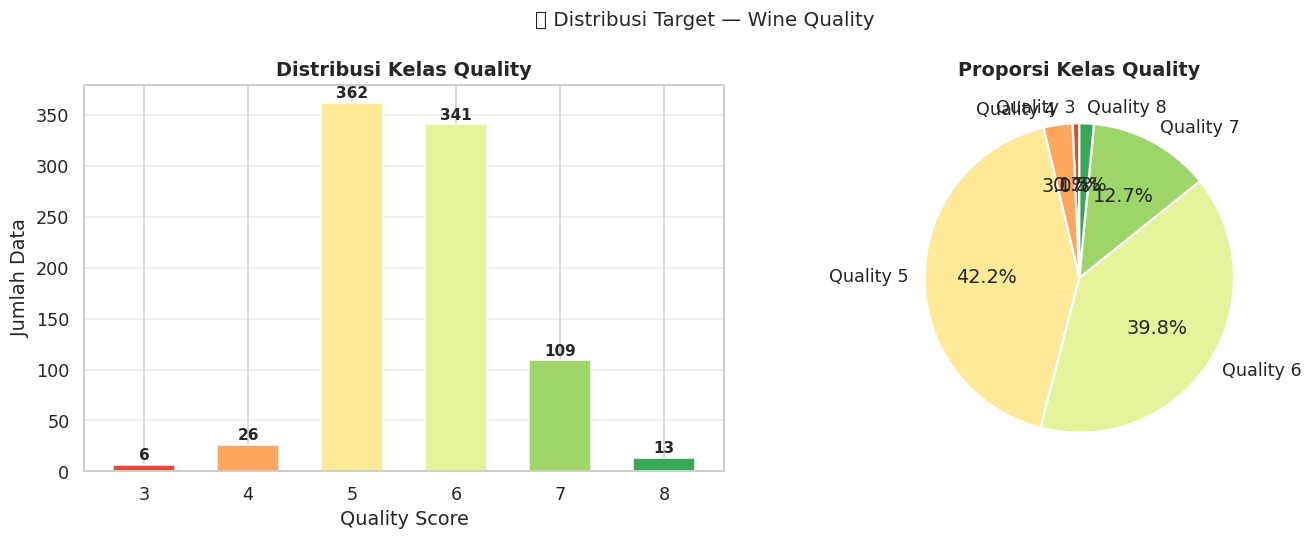


  💡 Dataset IMBALANCED: kelas 5 & 6 mendominasi (~82%)
     kelas 3 & 8 sangat sedikit (minoritas).
     RandomForest mampu menangani imbalanced class lebih baik
     dibanding model linier sederhana.

  ── Boxplot Fitur vs Quality ────────────────────────────────


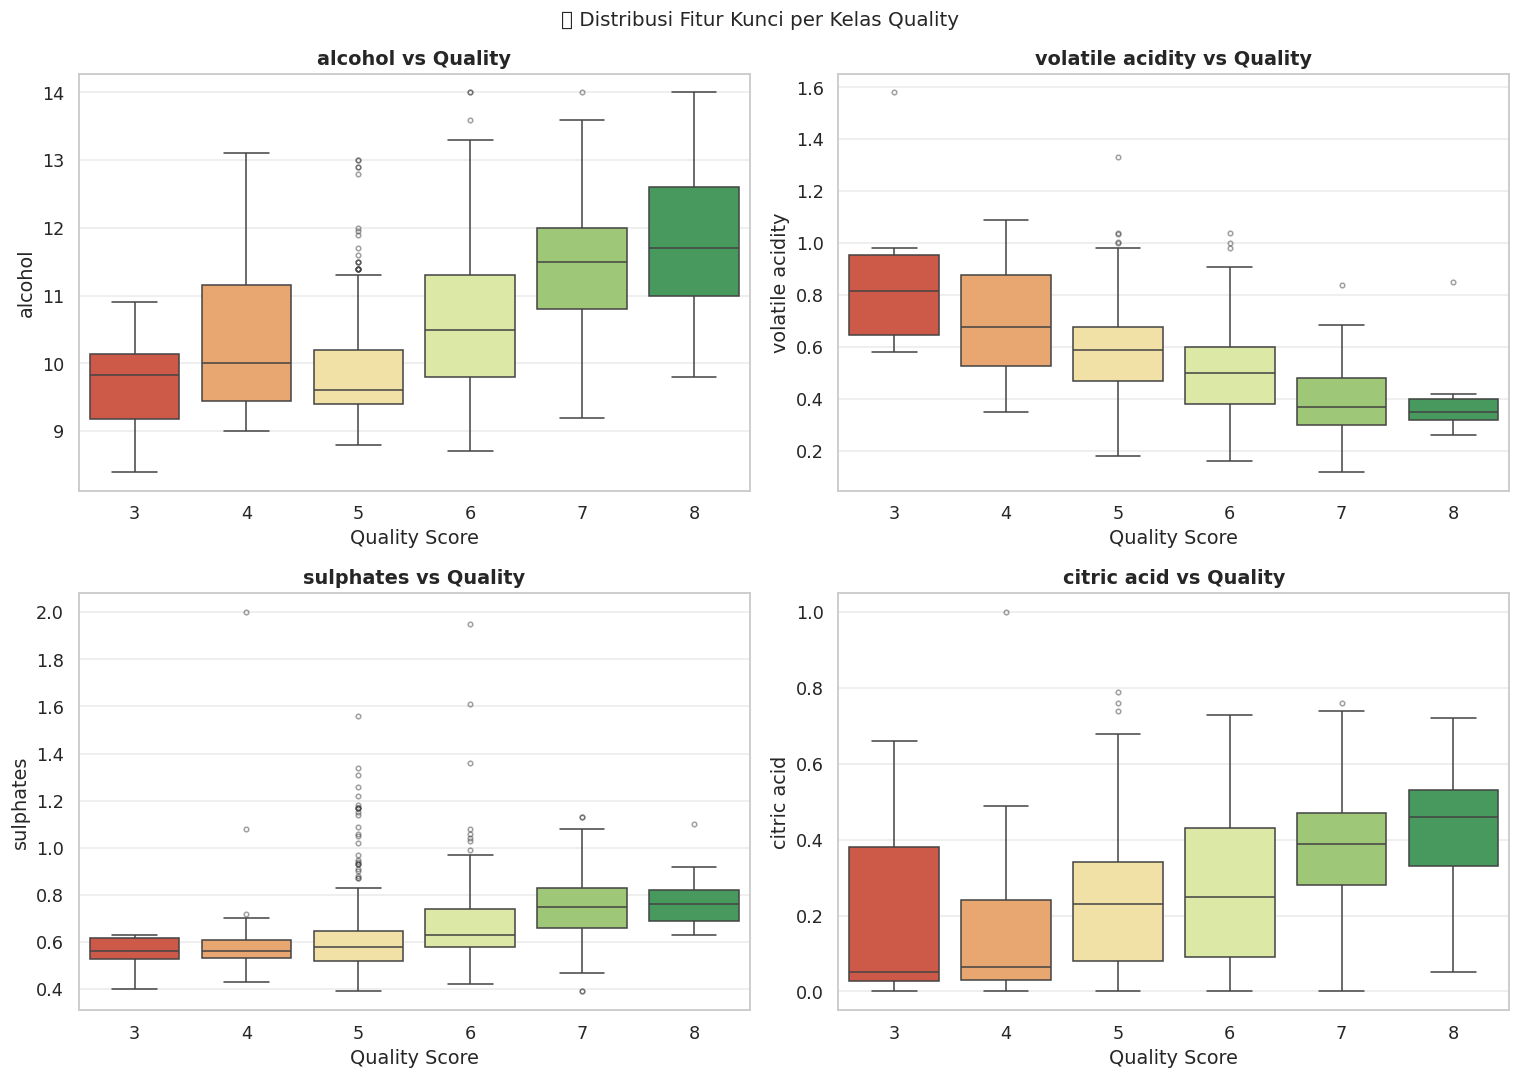


  💡 alcohol makin tinggi → quality cenderung lebih tinggi.
     volatile acidity makin rendah → quality lebih baik.


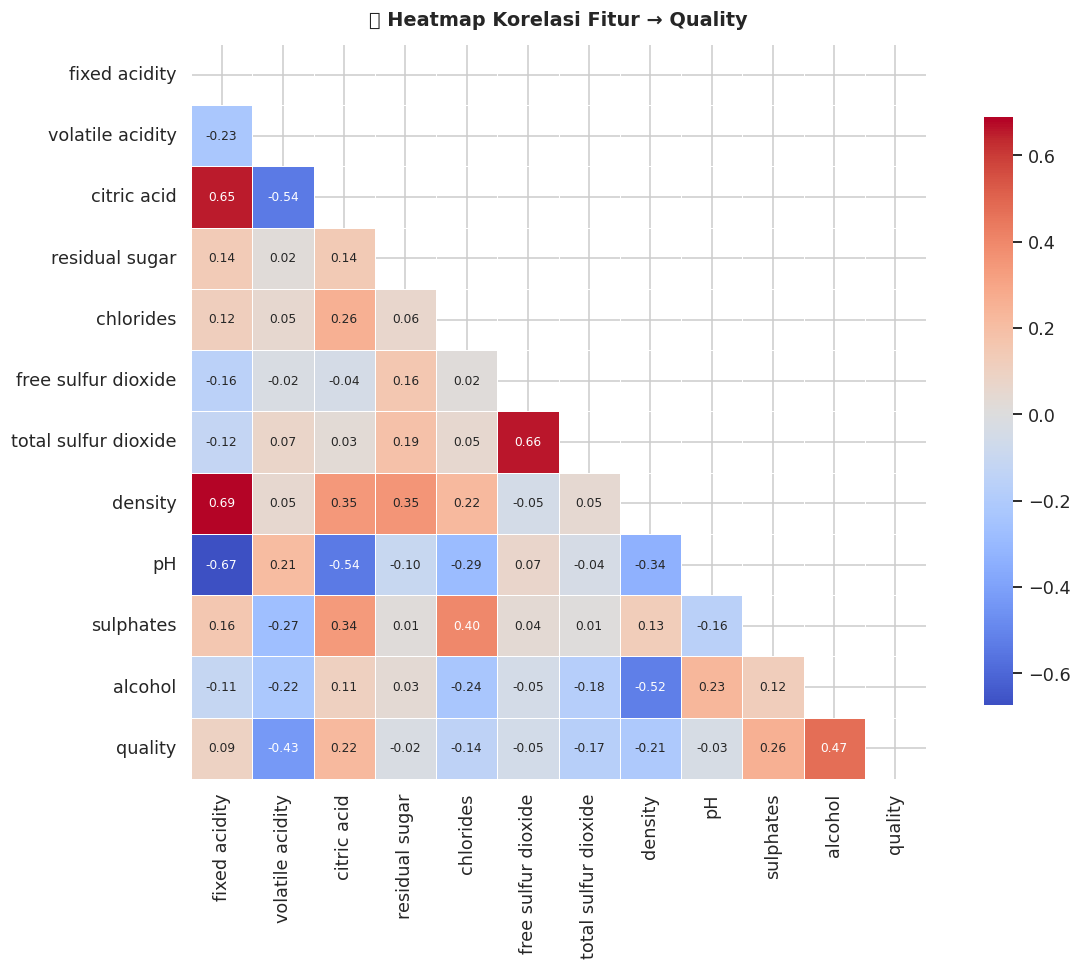


  💡 Korelasi terkuat ke quality:
     alcohol (+) | volatile acidity (-) | sulphates (+)


In [24]:
# ══════════════════════════════════════════════════════════════════
section('EXPLORATORY DATA ANALYSIS', '🔍')

FEATURE_COLS = ['fixed acidity', 'volatile acidity', 'citric acid',
                'residual sugar', 'chlorides', 'free sulfur dioxide',
                'total sulfur dioxide', 'density', 'pH',
                'sulphates', 'alcohol']

# ── Distribusi Kelas Target ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart kelas
colors_bar = sns.color_palette('RdYlGn', len(dist))
bars = axes[0].bar(dist.index.astype(str), dist.values,
                   color=colors_bar, edgecolor='white', width=0.6)
for bar, val in zip(bars, dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2, str(val),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Distribusi Kelas Quality')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Jumlah Data')
axes[0].grid(axis='y', alpha=0.4)

# Pie chart
axes[1].pie(dist.values, labels=[f'Quality {k}' for k in dist.index],
            autopct='%1.1f%%', colors=colors_bar,
            startangle=90, wedgeprops=dict(edgecolor='white', lw=1.5))
axes[1].set_title('Proporsi Kelas Quality')

fig.suptitle('📊 Distribusi Target — Wine Quality', fontsize=13)
plt.tight_layout(); plt.show()

print('\n  💡 Dataset IMBALANCED: kelas 5 & 6 mendominasi (~82%)')
print('     kelas 3 & 8 sangat sedikit (minoritas).')
print('     RandomForest mampu menangani imbalanced class lebih baik')
print('     dibanding model linier sederhana.')

# ── Distribusi Fitur per Kelas Quality ───────────────────────────
print('\n  ── Boxplot Fitur vs Quality ────────────────────────────────')
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    sns.boxplot(data=train, x='quality', y=feat,
                palette='RdYlGn', ax=axes[i],
                flierprops=dict(marker='o', markersize=3, alpha=0.5))
    axes[i].set_title(f'{feat} vs Quality')
    axes[i].set_xlabel('Quality Score')
    axes[i].grid(axis='y', alpha=0.4)
fig.suptitle('🍷 Distribusi Fitur Kunci per Kelas Quality', fontsize=13)
plt.tight_layout(); plt.show()
print('\n  💡 alcohol makin tinggi → quality cenderung lebih tinggi.')
print('     volatile acidity makin rendah → quality lebih baik.')

# ── Heatmap Korelasi ──────────────────────────────────────────────
corr = train[FEATURE_COLS + ['quality']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax, linewidths=0.5,
            square=True, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
ax.set_title('🔥 Heatmap Korelasi Fitur → Quality', pad=12)
plt.tight_layout(); plt.show()
print('\n  💡 Korelasi terkuat ke quality:')
print('     alcohol (+) | volatile acidity (-) | sulphates (+)')



4. PREPROCESSING DATA

In [25]:
section('PREPROCESSING DATA', '⚙️')

# ── 4a. Cek Missing Values ────────────────────────────────────────
print('\n  ── 4a. Missing Values ──────────────────────────────────────')
mv_train = train.isnull().sum().sum()
mv_test  = test.isnull().sum().sum()
print(f'  Training : {mv_train} missing  →  {"✅ Bersih" if mv_train == 0 else "⚠️ diimputasi"}')
print(f'  Testing  : {mv_test}  missing  →  {"✅ Bersih" if mv_test == 0 else "⚠️ diimputasi"}')

# Imputasi jika ada (aman dijalankan walau 0 missing)
train_num_cols = train.select_dtypes(include=[np.number]).columns
test_num_cols  = test.select_dtypes(include=[np.number]).columns
train[train_num_cols] = train[train_num_cols].fillna(train[train_num_cols].mean())
test[test_num_cols]   = test[test_num_cols].fillna(test[test_num_cols].mean())

# ── 4b. Pisahkan Fitur & Target ───────────────────────────────────
print('\n  ── 4b. Fitur & Target ──────────────────────────────────────')

# Training: drop target ('quality') dan ID ('Id')
X = train.drop(columns=['quality', 'Id'])
y = train['quality']

# Testing: drop ID ('Id') — perhatikan kapital 'I'
X_test_raw = test.drop(columns=['Id'])

print(f'  X (fitur training) : {X.shape}')
print(f'  y (target)         : {y.shape}  | kelas: {sorted(y.unique())}')
print(f'  X_test_raw         : {X_test_raw.shape}')
print(f'  Fitur              : {list(X.columns)}')

# ── 4c. Scaling ───────────────────────────────────────────────────
print('\n  ── 4c. StandardScaler ──────────────────────────────────────')
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)              # fit + transform training
test_scaled = scaler.transform(X_test_raw)      # transform saja (pakai scaler training)
print('  ✅ StandardScaler diterapkan (fit pada training, transform pada testing)')

# ── 4d. Split Train / Validation ─────────────────────────────────
print('\n  ── 4d. Train / Validation Split (80/20) ───────────────────')
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'  X_train : {X_train.shape}  ({len(X_train)/len(X_scaled)*100:.0f}%)')
print(f'  X_val   : {X_val.shape}   ({len(X_val)/len(X_scaled)*100:.0f}%)')
print('  ✅ Stratify=True → proporsi kelas dijaga seimbang di train & val')




╔══════════════════════════════════════════════════════════════╗
║  ⚙️  PREPROCESSING DATA                                         ║
╚══════════════════════════════════════════════════════════════╝

  ── 4a. Missing Values ──────────────────────────────────────
  Training : 0 missing  →  ✅ Bersih
  Testing  : 0  missing  →  ✅ Bersih

  ── 4b. Fitur & Target ──────────────────────────────────────
  X (fitur training) : (857, 11)
  y (target)         : (857,)  | kelas: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  X_test_raw         : (286, 11)
  Fitur              : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

  ── 4c. StandardScaler ──────────────────────────────────────
  ✅ StandardScaler diterapkan (fit pada training, transform pada testing)

  ── 4d. Train / Validation Split (80/20) ───────────────────
  X_train : (685, 1

5. TRAINING MODEL — RANDOM FOREST

In [26]:
section('TRAINING MODEL — RANDOM FOREST', '🤖')

model = RandomForestClassifier(
    n_estimators=200,        # jumlah pohon
    max_depth=None,          # biarkan tumbuh penuh
    min_samples_split=5,     # min sampel untuk split node
    min_samples_leaf=2,      # min sampel di leaf
    class_weight='balanced', # tangani imbalanced class
    random_state=42,
    n_jobs=-1                # pakai semua core CPU
)

print('\n  Parameter Random Forest:')
print(f'   n_estimators   : {model.n_estimators}')
print(f'   class_weight   : {model.class_weight}  (mengatasi imbalanced class)')
print(f'   random_state   : {model.random_state}')

model.fit(X_train, y_train)
print('\n  ✅  Model berhasil ditraining!')


╔══════════════════════════════════════════════════════════════╗
║  🤖  TRAINING MODEL — RANDOM FOREST                             ║
╚══════════════════════════════════════════════════════════════╝

  Parameter Random Forest:
   n_estimators   : 200
   class_weight   : balanced  (mengatasi imbalanced class)
   random_state   : 42

  ✅  Model berhasil ditraining!


6. EVALUASI MODEL (Validation Set)


╔══════════════════════════════════════════════════════════════╗
║  📊  EVALUASI MODEL                                             ║
╚══════════════════════════════════════════════════════════════╝

  ✅  Accuracy (Validation) : 0.6105  (61.05%)

  ── Classification Report ──────────────────────────────────
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.69      0.77      0.73        73
           6       0.58      0.60      0.59        68
           7       0.44      0.32      0.37        22
           8       1.00      0.33      0.50         3

    accuracy                           0.61       172
   macro avg       0.45      0.34      0.36       172
weighted avg       0.60      0.61      0.60       172


  ── Confusion Matrix ────────────────────────────────────────


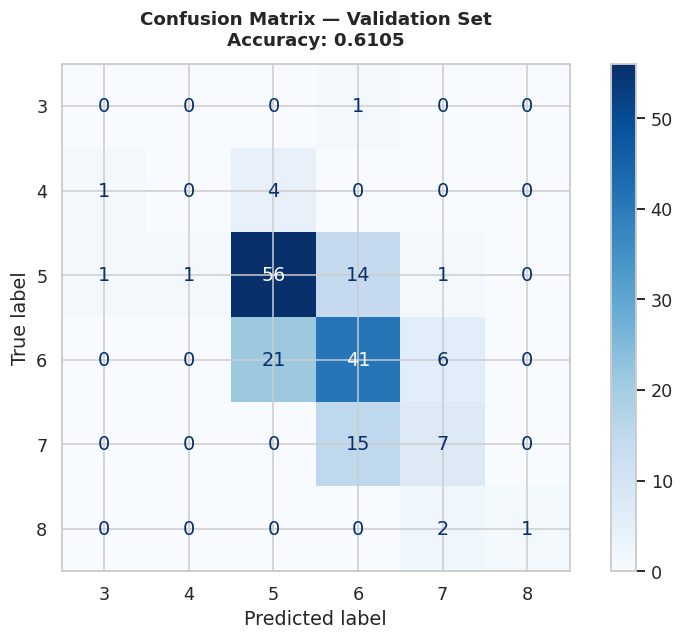


  💡 Diagonal = prediksi benar.
     Off-diagonal = kesalahan prediksi antar kelas.
     Kelas 5 & 6 paling banyak benar karena data dominan.

  ── Feature Importance ──────────────────────────────────────


,Fitur,Importance
0,volatile acidity,0.1496
1,sulphates,0.1277
2,alcohol,0.1196
3,total sulfur dioxide,0.0974
4,citric acid,0.0900
5,chlorides,0.0783
6,pH,0.0772
7,density,0.0759
8,fixed acidity,0.0647
9,free sulfur dioxide,0.0644


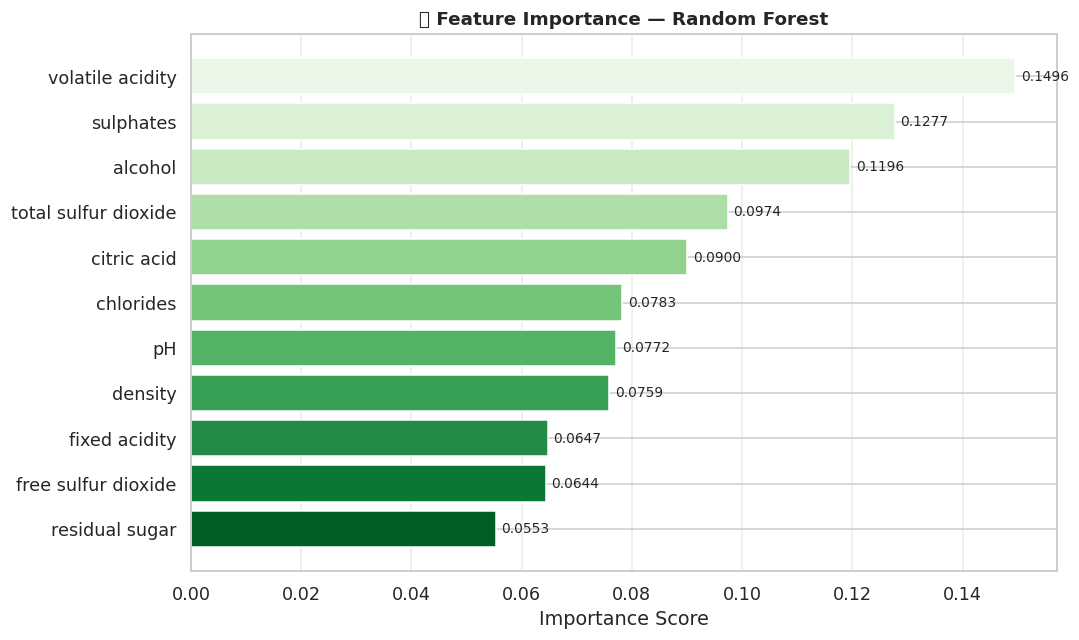


  🥇 Fitur paling penting: volatile acidity
  🥈 Fitur kedua        : sulphates
  🥉 Fitur ketiga       : alcohol


In [27]:
section('EVALUASI MODEL', '📊')

y_pred = model.predict(X_val)
acc = accuracy_score(y_val, y_pred)

print(f'\n  ✅  Accuracy (Validation) : {acc:.4f}  ({acc*100:.2f}%)')
print('\n  ── Classification Report ──────────────────────────────────')
print(classification_report(y_val, y_pred, zero_division=0))

# ── Confusion Matrix ──────────────────────────────────────────────
print('\n  ── Confusion Matrix ────────────────────────────────────────')
cm = confusion_matrix(y_val, y_pred, labels=sorted(y.unique()))
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=sorted(y.unique()))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — Validation Set\nAccuracy: {acc:.4f}',
             fontsize=12, pad=12)
plt.tight_layout(); plt.show()

print('\n  💡 Diagonal = prediksi benar.')
print('     Off-diagonal = kesalahan prediksi antar kelas.')
print('     Kelas 5 & 6 paling banyak benar karena data dominan.')

# ── Feature Importance ────────────────────────────────────────────
print('\n  ── Feature Importance ──────────────────────────────────────')
importance_df = pd.DataFrame({
    'Fitur'      : X.columns,
    'Importance' : model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

display(importance_df.style
        .background_gradient(subset=['Importance'], cmap='Greens')
        .format({'Importance': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance_df['Fitur'][::-1],
               importance_df['Importance'][::-1],
               color=sns.color_palette('Greens_r', len(importance_df)),
               edgecolor='white')
for bar, val in zip(bars, importance_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('🌲 Feature Importance — Random Forest', fontsize=12)
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

print(f'\n  🥇 Fitur paling penting: {importance_df.iloc[0]["Fitur"]}')
print(f'  🥈 Fitur kedua        : {importance_df.iloc[1]["Fitur"]}')
print(f'  🥉 Fitur ketiga       : {importance_df.iloc[2]["Fitur"]}')


7. TRAINING FINAL (Seluruh Data Training)

In [28]:
section('TRAINING FINAL — SELURUH DATA TRAINING', '🏋️')

model.fit(X_scaled, y)
print('\n  ✅  Model ditraining ulang menggunakan seluruh data training')
print(f'     (857 baris × {X_scaled.shape[1]} fitur)')
print('     → Model lebih kuat sebelum prediksi data testing.')


╔══════════════════════════════════════════════════════════════╗
║  🏋️  TRAINING FINAL — SELURUH DATA TRAINING                     ║
╚══════════════════════════════════════════════════════════════╝

  ✅  Model ditraining ulang menggunakan seluruh data training
     (857 baris × 11 fitur)
     → Model lebih kuat sebelum prediksi data testing.


8. PREDIKSI DATA TESTING


╔══════════════════════════════════════════════════════════════╗
║  🔮  PREDIKSI DATA TESTING                                      ║
╚══════════════════════════════════════════════════════════════╝

  ✅  Prediksi selesai!
     Jumlah data testing : 286
     Kelas yang diprediksi: [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

  ── Distribusi Hasil Prediksi ──────────────────────────────


quality,4,5,6,7,8
count,1,129,120,34,2


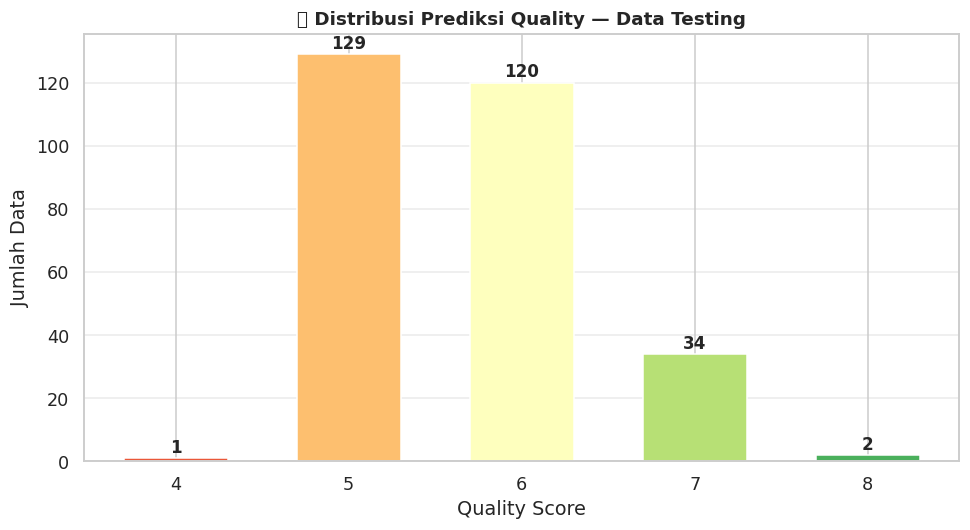


  ── Tabel Hasil Prediksi (Seluruh Data) ───────────────────


,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6
5,1120,7
6,180,5
7,82,5
8,632,5
9,592,5


In [29]:
section('PREDIKSI DATA TESTING', '🔮')

predictions = model.predict(test_scaled)

hasil = pd.DataFrame({
    'Id'     : test['Id'],
    'quality': predictions
})

print(f'\n  ✅  Prediksi selesai!')
print(f'     Jumlah data testing : {len(hasil):,}')
print(f'     Kelas yang diprediksi: {sorted(hasil["quality"].unique())}')

print('\n  ── Distribusi Hasil Prediksi ──────────────────────────────')
pred_dist = hasil['quality'].value_counts().sort_index()
display(pred_dist.to_frame().T)

# Visualisasi distribusi prediksi
fig, ax = plt.subplots(figsize=(9, 5))
colors_pred = sns.color_palette('RdYlGn', len(pred_dist))
bars = ax.bar(pred_dist.index.astype(str), pred_dist.values,
              color=colors_pred, edgecolor='white', width=0.6)
for bar, val in zip(bars, pred_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5, str(val),
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('🔮 Distribusi Prediksi Quality — Data Testing', fontsize=12)
ax.set_xlabel('Quality Score'); ax.set_ylabel('Jumlah Data')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()


print('\n  ── Tabel Hasil Prediksi (Seluruh Data) ───────────────────')
pd.set_option('display.max_rows', None)
display(hasil.style
        .background_gradient(subset=['quality'], cmap='RdYlGn')
        .set_caption('Hasil Prediksi Wine Quality — Seluruh Data Testing'))
pd.reset_option('display.max_rows')

 9. KESIMPULAN

In [31]:
section('KESIMPULAN', '📝')

print(f"""
  ╔═════════════════════════════════════════════════════════════╗
  ║         RINGKASAN — KLASIFIKASI WINE QUALITY                ║
  ╚═════════════════════════════════════════════════════════════╝

    DATASET
      Training : 857 baris  |  11 fitur kimia  |  6 kelas
      Testing  : 286 baris  |  11 fitur kimia
      Target   : quality (skala 3 – 8)
      Catatan  : imbalanced class (kelas 5 & 6 dominan ~82%)

    MODEL — Random Forest Classifier
      n_estimators  : 200 pohon
      class_weight  : balanced (mengatasi imbalanced)
      Accuracy Val  : {acc:.4f}  ({acc*100:.2f}%)

    FITUR TERPENTING
      1. {importance_df.iloc[0]["Fitur"]:<52}
      2. {importance_df.iloc[1]["Fitur"]:<52}
      3. {importance_df.iloc[2]["Fitur"]:<52}

    HASIL PREDIKSI TESTING
      Total prediksi   : {len(hasil):,} data
      Distribusi kelas : {dict(pred_dist.items())}

    OUTPUT
     Sebanyak 286 data testing telah diprediksi.
     Distribusi kelas hasil prediksi adalah: Kualitas 4 (1 data), 5 (129 data), 6 (120 data), 7 (34 data), dan 8 (2 data).



""")

print('  ✅  Pipeline klasifikasi selesai!')


╔══════════════════════════════════════════════════════════════╗
║  📝  KESIMPULAN                                                 ║
╚══════════════════════════════════════════════════════════════╝

  ╔═════════════════════════════════════════════════════════════╗
  ║         RINGKASAN — KLASIFIKASI WINE QUALITY                ║
  ╚═════════════════════════════════════════════════════════════╝

    DATASET
      Training : 857 baris  |  11 fitur kimia  |  6 kelas
      Testing  : 286 baris  |  11 fitur kimia
      Target   : quality (skala 3 – 8)
      Catatan  : imbalanced class (kelas 5 & 6 dominan ~82%)

    MODEL — Random Forest Classifier
      n_estimators  : 200 pohon
      class_weight  : balanced (mengatasi imbalanced)
      Accuracy Val  : 0.6105  (61.05%)

    FITUR TERPENTING
      1. volatile acidity                                    
      2. sulphates                                           
      3. alcohol                                             

    HASIL PRED